<center>
  <h1>Aritméticas Fuzzy</h1>
  <h3>Uma implementação computacional dos métodos mais comuns</h3>
  <b>Yasmin B. Shimizu</b>
</center>

---

<p style="text-align: center;">
  Parte do Projeto de Iniciação Científica <b>Estudo de interatividade e aritmética fuzzy com aplicações em quadrados mínimos fuzzy e problemas inversos</b> (FAPESP n° 2025/26138-6).
</p>

<center>
  <img src="https://github.com/yasminbshimizu/IC_Fuzzy_Aritmetica_Interatividade_QuadradosMinimosPI/blob/main/Images/logo_fapesp_ilum_sfundo.png?raw=true" width="1000"/>
</center>



In [1]:
import numpy as np
import matplotlib.pyplot as plt

##### Funções Suporte

In [2]:
def plota_oper_fuzzy(x1, x2, x_res, aniveis = [0,1,0], oper_str = "★", titulo = "A ★ B"):
    plt.plot(x1, aniveis, color = "darkblue", label = f"A = ({np.round(x1[0],3)}; {np.round(x1[len(x1)//2],3)}; {np.round(x1[-1],3)})")
    plt.plot(x2, aniveis, color = "deeppink", label = f"B = ({np.round(x2[0],)}; {np.round(x2[len(x1)//2],3)}; {np.round(x2[-1],3)})")
    plt.plot(x_res, aniveis, color = "indigo", label = f"A {oper_str} B = ({np.round(x_res[0],3)}; {np.round(x_res[len(x1)//2],3)}; {np.round(x_res[-1],3)})")
    plt.grid()
    plt.legend()
    plt.title(titulo)
    plt.xlabel("x")
    plt.ylabel("Pertinência")
    plt.show()

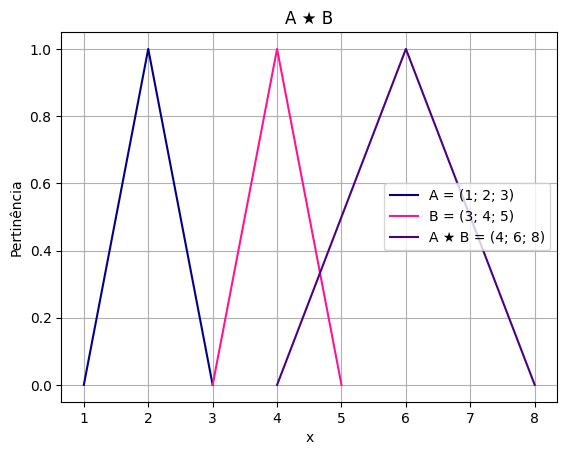

In [3]:
### EXEMPLO

A = (1,2,3)
B = (3,4,5)

S = (4, 6, 8)

plota_oper_fuzzy(A,B,S)

In [4]:
def n_fuzzy_sino(u, sigma, d, int_range = 2001):
    x_intervalo = np.linspace(u-d, u+d, int_range)
    alphas = np.exp(-((u - x_intervalo)**2 / sigma))
    return x_intervalo, alphas

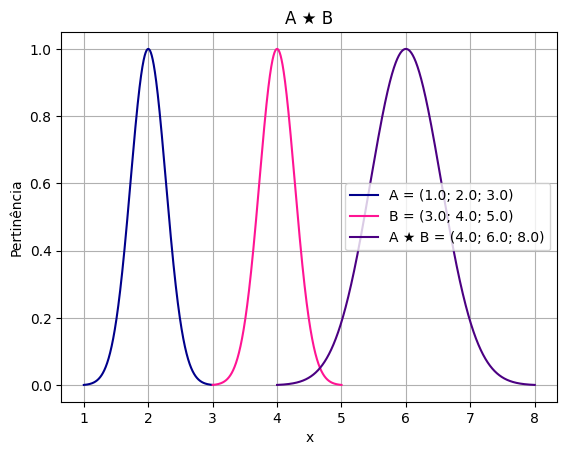

In [5]:
### EXEMPLO

A_sino, A_alpha = n_fuzzy_sino(2,0.15,1)
B_sino, B_alpha = n_fuzzy_sino(4,0.15,1)

S_sino = A_sino+B_sino

plota_oper_fuzzy(A_sino, B_sino, S_sino, aniveis = A_alpha)

In [6]:
def _aplica_funcao(x_data, f_expr):
    """
    Avalia a função f(x), definida por uma string, nos pontos de x_data e retorna os resultados como vetor coluna.

    Args:
        x_data (array-like): vetor coluna (n x 1) contendo os valores de entrada x₀ nos quais a função será avaliada.
        f_expr (str): Expressão representando a função f(x) interpretada via eval, por exemplo: "x**2 + 3*x - 1" ou "math.cos".
        
    Returns:
        results_f (np.ndarray): vetor coluna (n x 1) contendo os valores f(x₀) para cada x₀ em x_data.
    """
    
    # Criar função f(x) a partir da expressão f_expr
    f = lambda x: eval(f_expr)
    
    # Lista para armazenar os resultados de f(x0), x0 em x_data
    results_f = []
    
    # Itera sobre os valores em x_data e calcula f(x)
    for x in x_data:
        results_f.append(f(x[0]))
        
    # Transforma results_f em uma matriz coluna com cada valor f(x0), x0 em x_data
    results_f = np.array(results_f)
    
    results_f = results_f.reshape(-1,1)
    
    return results_f


In [7]:
def f_alpha_ntrifuzzy(ntri):
    """
    Define um número triangular fuzzy em função de seus alpha-níveis.

    Args:
        nt (tuple or array-like): número triangular fuzzy x na forma x = (a,b,c).
        
    Returns:
        alphaf (list of str): lista contendo a expressão algébrica que representa x em função de seus alpha-níveis.
    """
    
    a,b,c = ntri
    
    alpha1 = f"x*({b}-{a}) + {a}"
    alpha2 = f"-x*({c}-{b}) + {c}"
    
    alphaf = [alpha1, alpha2]
    
    return alphaf


In [8]:
def f_alpha_ntrapfuzzy(ntrap):
    """
    Define um número triangular fuzzy em função de seus alpha-níveis.

    Args:
        nt (tuple or array-like): número triangular fuzzy x na forma x = (a,b,c).
        
    Returns:
        alphaf (list of str): lista contendo a expressão algébrica que representa x em função de seus alpha-níveis.
    """
    
    a,b,c,d = ntrap
    
    alpha1 = f"x*({b}-{a}) + {a}"
    alpha2 = f"-x*({d}-{c}) + {d}"
    
    alphaf = [alpha1, alpha2]
    
    return alphaf

In [9]:
def alpha_niveis(n, range_alpha = 1001):
    if len(n) == 3:
        f_alpha_nfuzzy = f_alpha_ntrifuzzy
    elif len(n) == 4:
        f_alpha_nfuzzy = f_alpha_ntrapfuzzy
        
    f = f_alpha_nfuzzy(n)
    
    alpha = np.linspace(0,1, range_alpha)
    alpha_ = alpha[::-1]
    alpha_re = alpha.reshape((-1,1))
    
    an1 = _aplica_funcao(alpha_re, f[0])
    an2 = _aplica_funcao(alpha_re, f[1])
    an2 = an2[::-1]
    
    aniveis = np.concatenate([an1, an2[1:]])
    alphas = np.concatenate([alpha, alpha_[1:]])
    
    return aniveis, alphas
    

## Soma

---

### Soma Usual

$$     
        [P+Q]^\alpha = [P]^\alpha + [Q]^\alpha = [\,p_1^\alpha + q_1^\alpha,\; p_2^\alpha + q_2^\alpha\,]
$$

In [10]:
def soma_fuzzy(x1, x2):
    """
    Realiza a soma fuzzy usual entre dois números fuzzy.

    Args:
        x1 (tuple or array-like): número fuzzy x1, podendo representar seus alpha-níveis ou um número triangular fuzzy na forma x1 = (a,b,c).
        x2 (tuple or array-like): número fuzzy x2, podendo representar seus alpha-níveis ou um número triangular fuzzy na forma x2 = (d,e,f).

    Returns:
        x_soma (tuple): número fuzzy resultante da soma usual.
        
    """
    
    if len(x1) != len(x2):
        raise ValueError("Os números fuzzy x1 e x2 devem ter o mesmo número de alpha-níveis.")

    x_soma = (a+b for a,b in zip(x1,x2))
    
#     x_soma = []
#     for i in range(len(x1)):
#         x_soma.append(x1[i] + x2[i])
        
    x_soma = tuple(x_soma)
    
    return x_soma

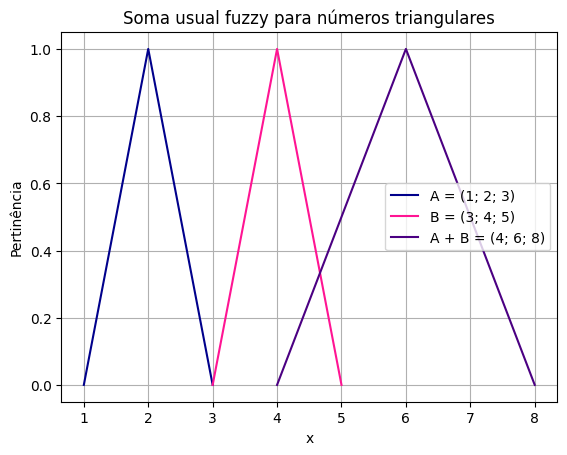

In [11]:
### EXEMPLO

A = (1,2,3)
B = (3,4,5)

S = soma_fuzzy(A, B)

plota_oper_fuzzy(A,B,S, oper_str="+", titulo = "Soma usual fuzzy para números triangulares")

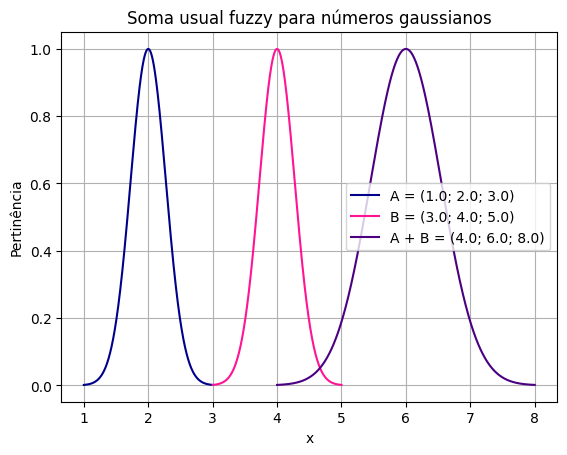

In [12]:
### EXEMPLO

A_sino, A_alpha = n_fuzzy_sino(2,0.15,1)
B_sino, B_alpha = n_fuzzy_sino(4,0.15,1)

S_sino = soma_fuzzy(A_sino, B_sino)

plota_oper_fuzzy(A_sino, B_sino, S_sino, aniveis = A_alpha, oper_str="+", titulo = "Soma usual fuzzy para números gaussianos")

### Soma Interativa

#### Soma Interativa $+_0$

$$P+_0Q = \begin{cases}
((p_a+q_c) \land (p_b+q_b); p_b+q_b ; (p_b+q_b) \lor (p_c+q_a)), \text{se diam(P)} \geq \text{diam (Q)} \\
((p_c+q_a) \land (p_b+q_b); p_b+q_b ; (p_b+q_b) \lor (p_a+q_c)), \text{se diam(P)} \leq \text{diam (Q)}
\end{cases}.$$

In [13]:
def soma_interativa_0 (x1,x2):
    """
    Realiza a soma otimista (gamma zero) de dois números triangulares fuzzy, segundo Wasques et al. (2020b).

    Args:
        x1 (tuple or array-like): número triangular fuzzy x1 na forma x1 = (a,b,c).
        x2 (tuple or array-like): número triangular fuzzy x2 na forma x2 = (d,e,f).

    Returns:
        x_soma (tuple): número triangular fuzzy resultante da soma otimista.
        
    """
    
    #define uma lista vazia para armazenar o resultado
    x_soma = []
    
    #renomeia cada componente dos números fuzzy a serem somados
    a,b,c = x1
    d,e,f = x2
    
    #define os valores dos diâmetros dos números fuzzy
    diam_x1 = c - a
    diam_x2 = f - d
    
    #define as somas entre picos, maior e menor, e menor e maior componente dos números fuzzy
    s_picos = b+e
    s_meios = c+d
    s_extremos = a+f
    
    #realiza a soma fuzy seguindo as condições de diâmetro
    if diam_x1 >= diam_x2: # se o diâmetro do primeiro for maior que o do segundo
        x_soma.append(min(s_extremos, s_picos)) # escolhe a menor soma entre picos ou extremos para definir o menor componente da soma
        x_soma.append(s_picos) # soma os picos para definir o pico da soma
        x_soma.append(max(s_picos, s_meios)) # escolhe a maior soma entre picos ou meios para definir o maior componente da soma
        
    elif diam_x1 <= diam_x2: # se o diâmetro do primeiro for menor que o do segundo
        x_soma.append(min(s_picos, s_meios)) # escolhe a menor soma entre picos e meios para definir o menor componente da soma
        x_soma.append(s_picos) # soma os picos para definir o pico da soma
        x_soma.append(max(s_extremos, s_picos)) # escolhe a maior soma entre picos e extremos para definir o maior componente da soma
        
    #transforma a lista "soma" em uma tupla imutável, notação utilizada para números fuzzy neste trabalho
    x_soma = tuple(x_soma)
    
    return x_soma    

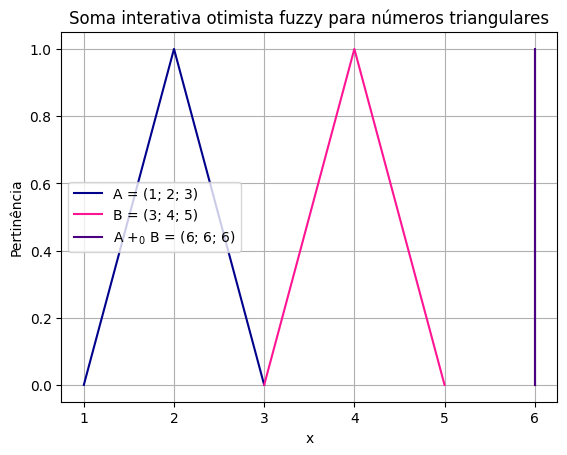

In [14]:
### EXEMPLO

A = (1,2,3)
B = (3,4,5)

S = soma_interativa_0(A, B)

plota_oper_fuzzy(A,B,S, oper_str="$+_0$", titulo = "Soma interativa otimista fuzzy para números triangulares")

## Subtração

---

### Subtração Usual

$$        [P - Q]^\alpha = [P]^\alpha - [Q]^\alpha = [\,p_1^\alpha - q_2^\alpha,\; p_2^\alpha - q_1^\alpha\,] 
$$

In [15]:
def dif_fuzzy(x1, x2):
    """
    Realiza a diferença fuzzy usual entre dois números fuzzy.

    Args:
        x1 (tuple or array-like): número fuzzy x1, podendo representar seus alpha-níveis ou um número triangular fuzzy na forma x1 = (a,b,c).
        x2 (tuple or array-like): número fuzzy x2, podendo representar seus alpha-níveis ou um número triangular fuzzy na forma x2 = (d,e,f).

    Returns:
        x_dif (tuple): número fuzzy resultante da diferença usual.
        
    """
    
    if len(x1) != len(x2):
        raise ValueError("Os números fuzzy x1 e x2 devem ter os mesmos alpha-níveis.")
        
    x2_ = x2[::-1]
    x_dif = (a-b for a,b in zip(x1,x2_))
    
#     x_dif = []
#     for i in range(len(x1)):
#         x_dif.append(x1[i] - x2_[i])
        
    x_dif = tuple(x_dif)
    
    return x_dif

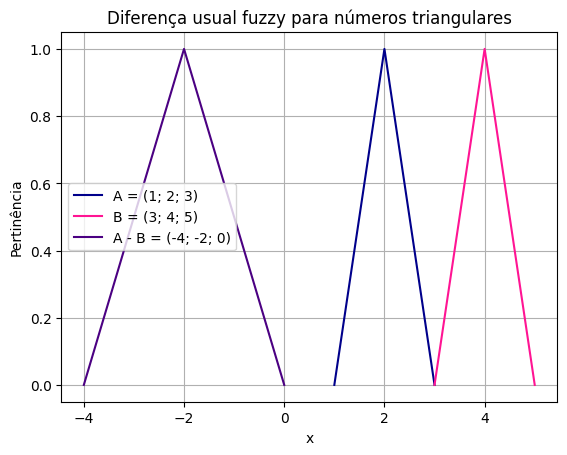

In [16]:
### EXEMPLO

A = (1,2,3)
B = (3,4,5)

D = dif_fuzzy(A, B)

plota_oper_fuzzy(A,B,D, oper_str="-", titulo = "Diferença usual fuzzy para números triangulares")

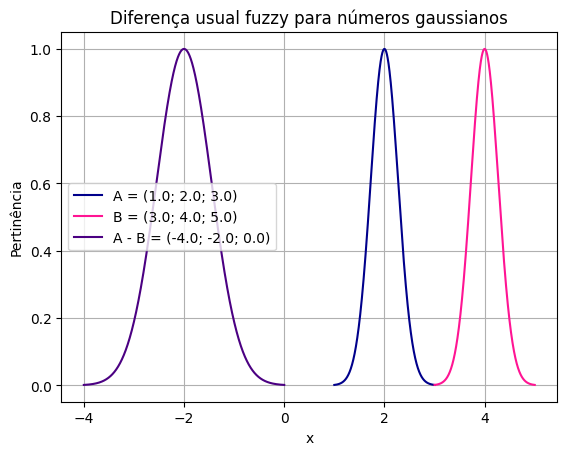

In [17]:
### EXEMPLO

A_sino, A_alpha = n_fuzzy_sino(2,0.15,1)
B_sino, B_alpha = n_fuzzy_sino(4,0.15,1)

D_sino = dif_fuzzy(A_sino, B_sino)

plota_oper_fuzzy(A_sino, B_sino, D_sino, aniveis = A_alpha, oper_str="-", titulo = "Diferença usual fuzzy para números gaussianos")

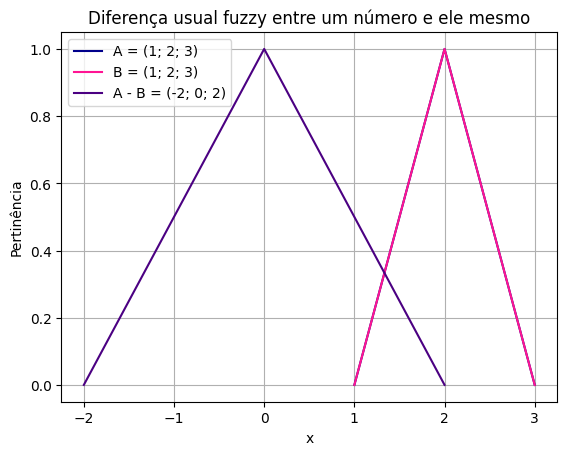

In [18]:
### EXEMPLO

A = (1,2,3)

Z = dif_fuzzy(A, A)

plota_oper_fuzzy(A,A,Z, oper_str="-", titulo = "Diferença usual fuzzy entre um número e ele mesmo")

### Subtrações Interativas

#### Diferença de Hukuhara ou H-diferença ($-_H$)

$$
[R]^\alpha = [P -_H Q]^\alpha =  [p_1^\alpha - q_1^\alpha, p_2^\alpha - q_2^\alpha],\quad\forall \alpha \in [0,1].
$$

In [19]:
def dif_hukuhara(x1, x2):
    """
    Realiza a diferença de Hukuhara entre dois números fuzzy.

    Args:
        x1 (tuple or array-like): número fuzzy x1, podendo representar seus alpha-níveis ou um número triangular fuzzy na forma x1 = (a,b,c).
        x2 (tuple or array-like): número fuzzy x2, podendo representar seus alpha-níveis ou um número triangular fuzzy na forma x2 = (d,e,f).

    Returns:
        x_dif (tuple): número fuzzy resultante da diferença de Hukuhara.
        
    """
    
    if len(x1) != len(x2):
        raise ValueError("Os números fuzzy x1 e x2 devem ter os mesmos alpha-níveis.")
        
    x_dif = (a-b for a,b in zip(x1,x2))
    
#     x_dif = []
#     for i in range(len(x1)):
#         x_dif.append(x1[i] - x2_[i])
        
    x_dif = tuple(x_dif)
    
    return x_dif

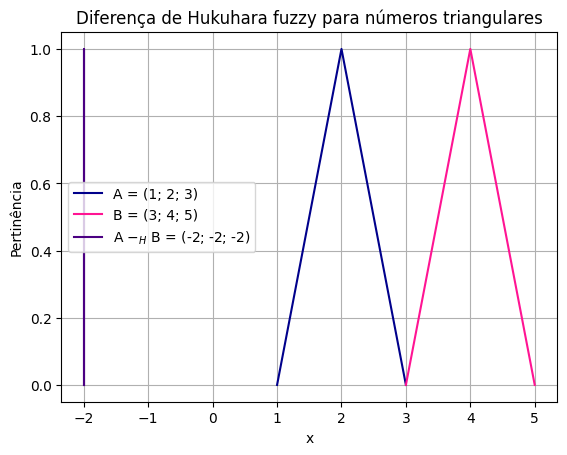

In [20]:
### EXEMPLO

A = (1,2,3)
B = (3,4,5)

D = dif_hukuhara(A, B)

plota_oper_fuzzy(A,B,D, oper_str="$-_H$", titulo = "Diferença de Hukuhara fuzzy para números triangulares")

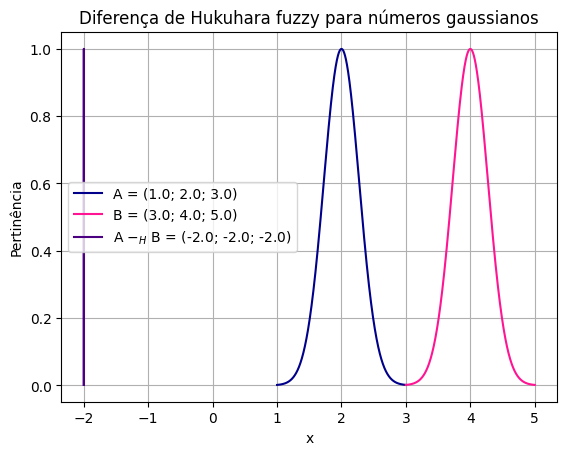

In [21]:
### EXEMPLO

A_sino, A_alpha = n_fuzzy_sino(2,0.15,1)
B_sino, B_alpha = n_fuzzy_sino(4,0.15,1)

D_sino = dif_hukuhara(A_sino, B_sino)

plota_oper_fuzzy(A_sino, B_sino, D_sino, aniveis = A_alpha, oper_str="$-_H$", titulo = "Diferença de Hukuhara fuzzy para números gaussianos")

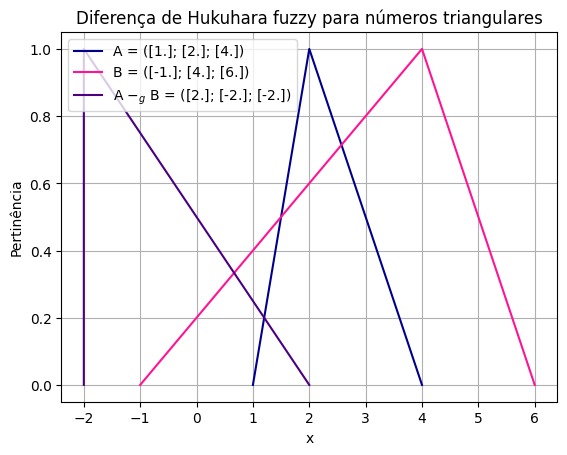

In [22]:
### EXEMPLO

A, alphas = alpha_niveis((1,2,4))
B, alphas = alpha_niveis((-1,4,6))

D = dif_hukuhara(A, B)

plota_oper_fuzzy(A,B,D, aniveis = alphas, oper_str="$-_{g}$", titulo = "Diferença de Hukuhara fuzzy para números triangulares")

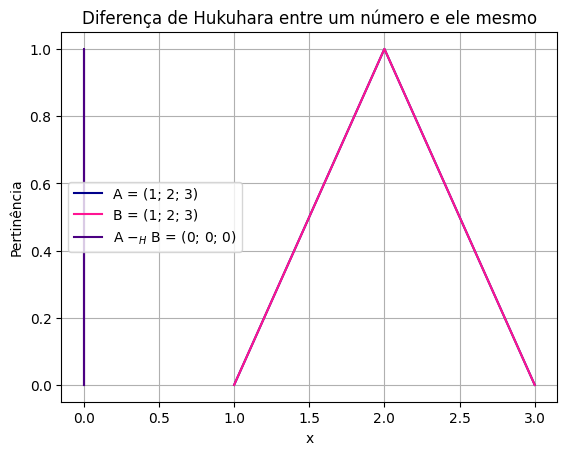

In [23]:
### EXEMPLO

A = (1,2,3)

Z = dif_hukuhara(A, A)

plota_oper_fuzzy(A,A,Z, oper_str="$-_H$", titulo = "Diferença de Hukuhara entre um número e ele mesmo")

##### Diferença de Hukuhara Generalizada ou gH-diferença ($-_{gH}$)

 $$
 [R]^\alpha =[P -_{gH} Q]^\alpha =  [\text{min}\{p_1^\alpha - q_1^\alpha; p_2^\alpha - q_2^\alpha\}, \text{max}\{p_1^\alpha - q_1^\alpha; p_2^\alpha - q_2^\alpha\}],\quad  \forall \alpha \in [0,1].
$$

In [24]:
def dif_ghuk(x1, x2):
    """
    Realiza a diferença de Hukuhara entre dois números fuzzy.

    Args:
        x1 (tuple or array-like): número fuzzy x1, podendo representar seus alpha-níveis ou um número triangular fuzzy na forma x1 = (a,b,c).
        x2 (tuple or array-like): número fuzzy x2, podendo representar seus alpha-níveis ou um número triangular fuzzy na forma x2 = (d,e,f).

    Returns:
        x_dif (tuple): número fuzzy resultante da diferença de Hukuhara.
        
    """
    
    if len(x1) != len(x2):
        raise ValueError("Os números fuzzy x1 e x2 devem ter os mesmos alpha-níveis.")
        
    len_meio = len(x1)//2
    
    x11 = x1[:len_meio]
    x12 = x1[len_meio+1:]
    x21 = x2[:len_meio]
    x22 = x2[len_meio+1:]
    
    x12 = x12[::-1]
    x22 = x22[::-1]
    
    x1_pico = x1[len_meio]
    x2_pico = x2[len_meio]
        
    x_dif1 = [min(a1-b1, a2-b2) for a1,b1,a2,b2 in zip(x11,x21,x12,x22)]
    x_dif2 = [max(a1-b1, a2-b2) for a1,b1,a2,b2 in zip(x11,x21,x12,x22)]
    
    x_dif2 = x_dif2[::-1]
    
    x_dif_pico = [x1_pico - x2_pico]
    
    x_dif = x_dif1+x_dif_pico+x_dif2
    
#     x_dif = []
#     for i in range(len(x1)):
#         x_dif.append(x1[i] - x2_[i])
        
    x_dif = tuple(x_dif)
    
    return x_dif

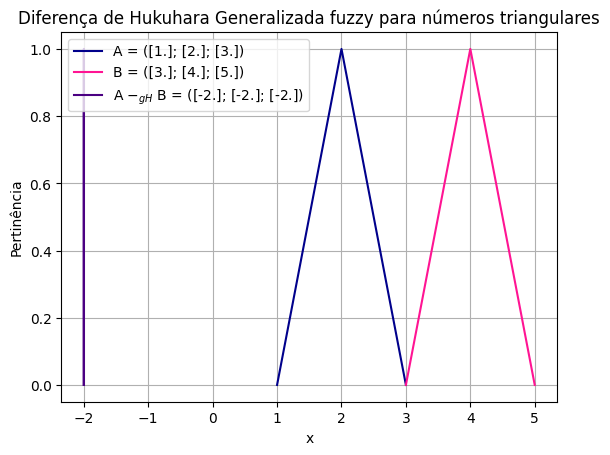

In [25]:
### EXEMPLO

A, alphas = alpha_niveis((1,2,3))
B, alphas = alpha_niveis((3,4,5))

D = dif_ghuk(A, B)

plota_oper_fuzzy(A,B,D, aniveis = alphas, oper_str="$-_{gH}$", titulo = "Diferença de Hukuhara Generalizada fuzzy para números triangulares")

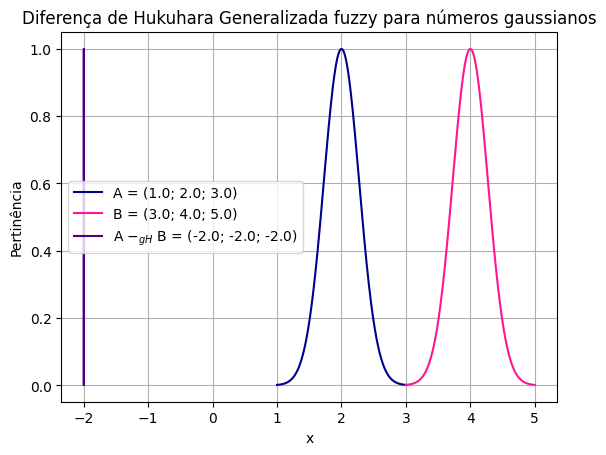

In [26]:
### EXEMPLO

A_sino, A_alpha = n_fuzzy_sino(2,0.15,1)
B_sino, B_alpha = n_fuzzy_sino(4,0.15,1)

D_sino = dif_ghuk(A_sino, B_sino)

plota_oper_fuzzy(A_sino, B_sino, D_sino, aniveis = A_alpha, oper_str="$-_{gH}$", titulo = "Diferença de Hukuhara Generalizada fuzzy para números gaussianos")

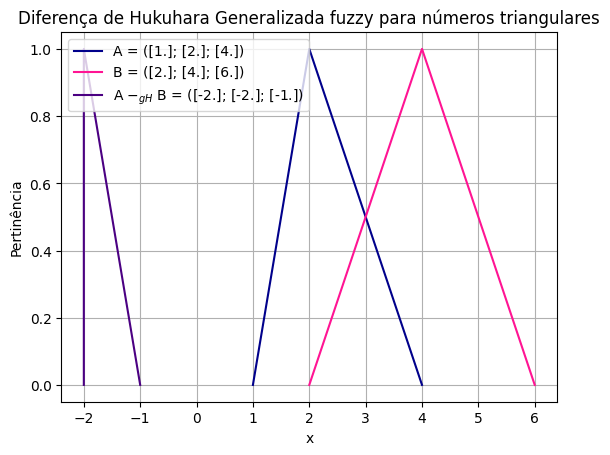

In [27]:
### EXEMPLO

A, alphas = alpha_niveis((1,2,4))
B, alphas = alpha_niveis((2,4,6))

D = dif_ghuk(A, B)

plota_oper_fuzzy(A,B,D, aniveis = alphas, oper_str="$-_{gH}$", titulo = "Diferença de Hukuhara Generalizada fuzzy para números triangulares")

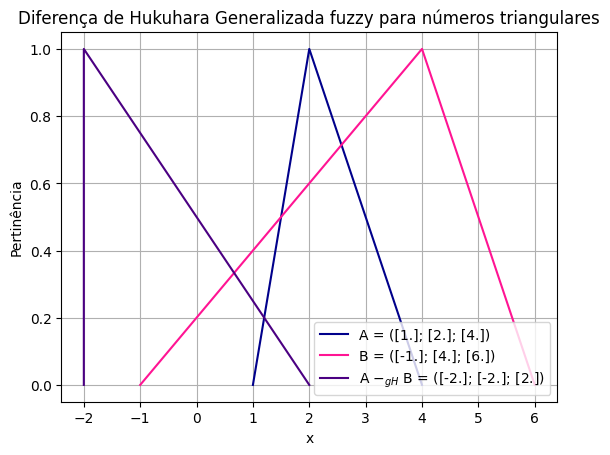

In [28]:
### EXEMPLO

A, alphas = alpha_niveis((1,2,4))
B, alphas = alpha_niveis((-1,4,6))

D = dif_ghuk(A, B)

plota_oper_fuzzy(A,B,D, aniveis = alphas, oper_str="$-_{gH}$", titulo = "Diferença de Hukuhara Generalizada fuzzy para números triangulares")

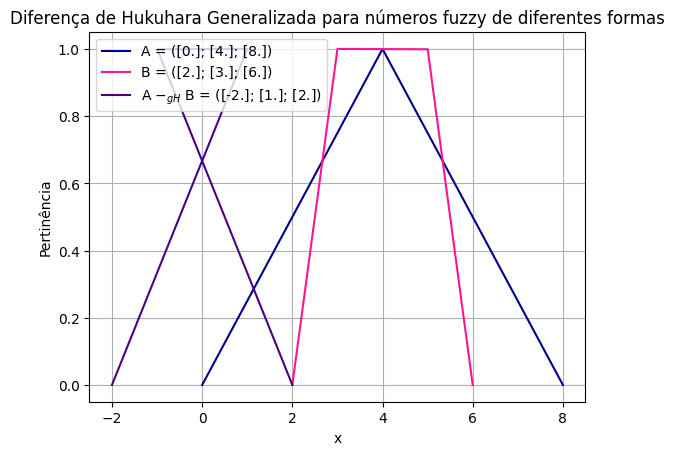

In [29]:
### EXEMPLO

A, alphas = alpha_niveis((0,4,8))
B, alphas = alpha_niveis((2,3,5,6))
### corrigir ghuk para aceitar n° de alpha níveis par
### corrigir plota_oper_fuzzy para aceitar n° de alpha níveis par

D = dif_ghuk(A, B)

plota_oper_fuzzy(A,B,D, aniveis = alphas, oper_str="$-_{gH}$", titulo = "Diferença de Hukuhara Generalizada para números fuzzy de diferentes formas")

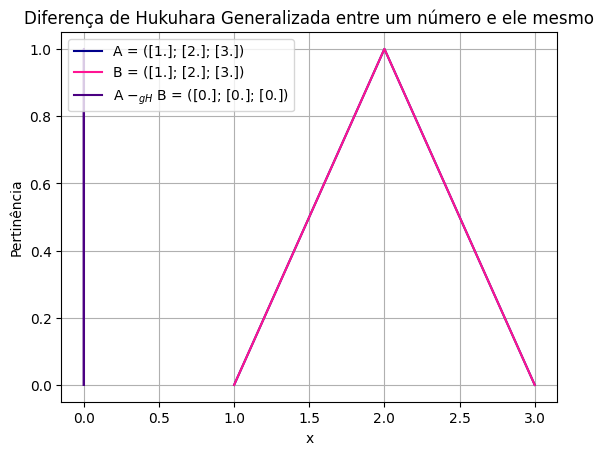

In [30]:
### EXEMPLO

A, alphas = alpha_niveis((1,2,3))

Z = dif_ghuk(A, A)

plota_oper_fuzzy(A,A,Z, aniveis = alphas, oper_str="$-_{gH}$", titulo = "Diferença de Hukuhara Generalizada entre um número e ele mesmo")

#### Diferença Generalizada ou g-diferença ($-_g$)

 $$
 [P -_g Q]^\alpha =  \left[\inf\limits_{\beta \geq \alpha} \text{min}\{p_1^\beta - q_1^\beta; p_2^\beta - q_2^\beta\}, \sup\limits_{\beta \geq \alpha}  \text{max}\{p_1^\beta - q_1^\beta; p_2^\beta - q_2^\beta\}\right], \quad    \forall \alpha \in [0,1].
$$

In [31]:
def dif_g(x1, x2):
    """
    Realiza a diferença de Hukuhara entre dois números fuzzy.

    Args:
        x1 (tuple or array-like): número fuzzy x1, podendo representar seus alpha-níveis ou um número triangular fuzzy na forma x1 = (a,b,c).
        x2 (tuple or array-like): número fuzzy x2, podendo representar seus alpha-níveis ou um número triangular fuzzy na forma x2 = (d,e,f).

    Returns:
        x_dif (tuple): número fuzzy resultante da diferença de Hukuhara.
        
    """
    
    if len(x1) != len(x2):
        raise ValueError("Os números fuzzy x1 e x2 devem ter os mesmos alpha-níveis.")
        
    len_meio = len(x1)//2
    
    x11 = x1[:len_meio]
    x12 = x1[len_meio+1:]
    x21 = x2[:len_meio]
    x22 = x2[len_meio+1:]
    
    x12 = x12[::-1]
    x22 = x22[::-1]
    
    x11_ = x11[::-1]
    x12_ = x12[::-1]
    x21_ = x21[::-1]
    x22_ = x22[::-1]
    
    x1_pico = x1[len_meio]
    x2_pico = x2[len_meio]
        
    x_dif1_ = [x1_pico - x2_pico]
    x_dif2_ = [x1_pico - x2_pico]
    
    for a1,b1,a2,b2 in zip(x11_,x21_,x12_,x22_):    
        alpha_dif1 = min(a1-b1, a2-b2, *x_dif1_)
        alpha_dif2 = max(a1-b1, a2-b2, *x_dif2_)
        
        x_dif1_.append(alpha_dif1)
        x_dif2_.append(alpha_dif2) 
    
    x_dif1 = x_dif1_[::-1]
    x_dif2 = x_dif2_[::-1]
    
    x_dif2 = x_dif2[::-1]
    
    x_dif = x_dif1+x_dif2[1:]
    
#     x_dif = []
#     for i in range(len(x1)):
#         x_dif.append(x1[i] - x2_[i])
        
    x_dif = tuple(x_dif)
    
    return x_dif

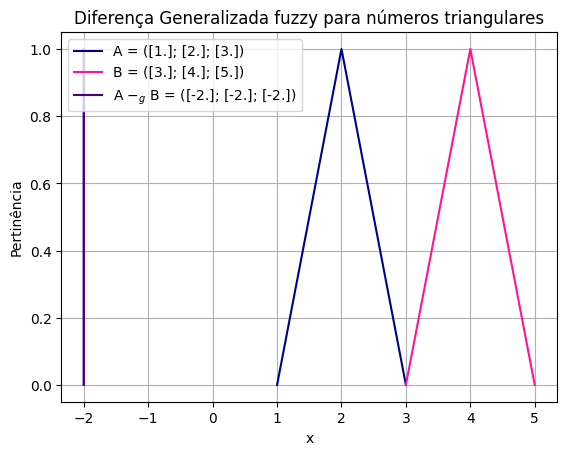

In [32]:
### EXEMPLO

A, alphas = alpha_niveis((1,2,3))
B, alphas = alpha_niveis((3,4,5))

D = dif_g(A, B)

plota_oper_fuzzy(A,B,D, aniveis = alphas, oper_str="$-_{g}$", titulo = "Diferença Generalizada fuzzy para números triangulares")

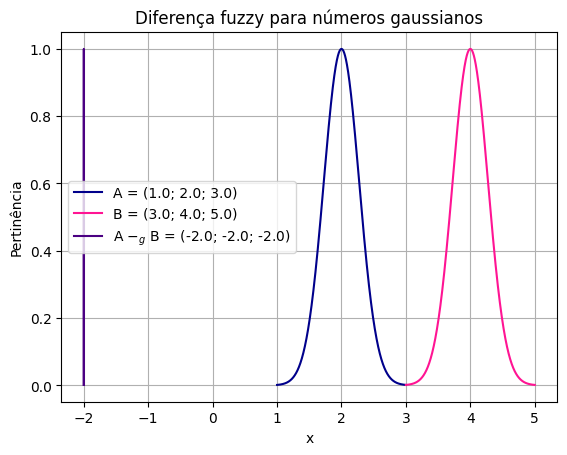

In [33]:
### EXEMPLO

A_sino, A_alpha = n_fuzzy_sino(2,0.15,1)
B_sino, B_alpha = n_fuzzy_sino(4,0.15,1)

D_sino = dif_g(A_sino, B_sino)

plota_oper_fuzzy(A_sino, B_sino, D_sino, aniveis = A_alpha, oper_str="$-_{g}$", titulo = "Diferença fuzzy para números gaussianos")

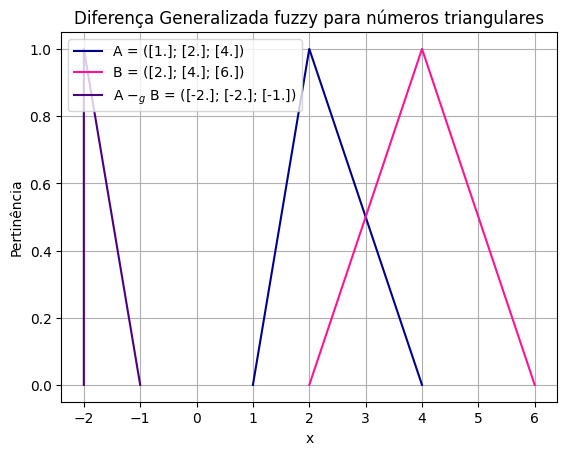

In [34]:
### EXEMPLO

A, alphas = alpha_niveis((1,2,4))
B, alphas = alpha_niveis((2,4,6))

D = dif_g(A, B)

plota_oper_fuzzy(A,B,D, aniveis = alphas, oper_str="$-_{g}$", titulo = "Diferença Generalizada fuzzy para números triangulares")

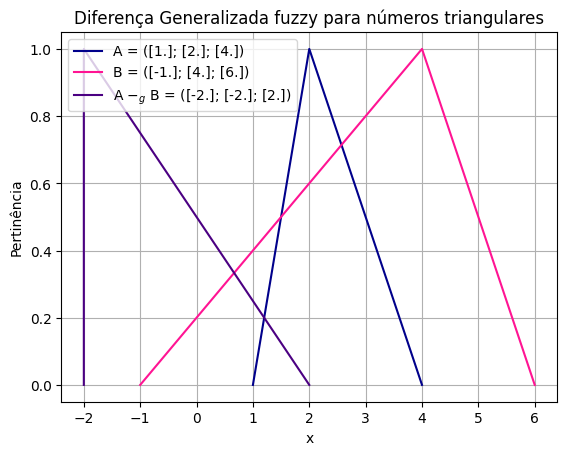

In [35]:
### EXEMPLO

A, alphas = alpha_niveis((1,2,4))
B, alphas = alpha_niveis((-1,4,6))

D = dif_g(A, B)

plota_oper_fuzzy(A,B,D, aniveis = alphas, oper_str="$-_{g}$", titulo = "Diferença Generalizada fuzzy para números triangulares")

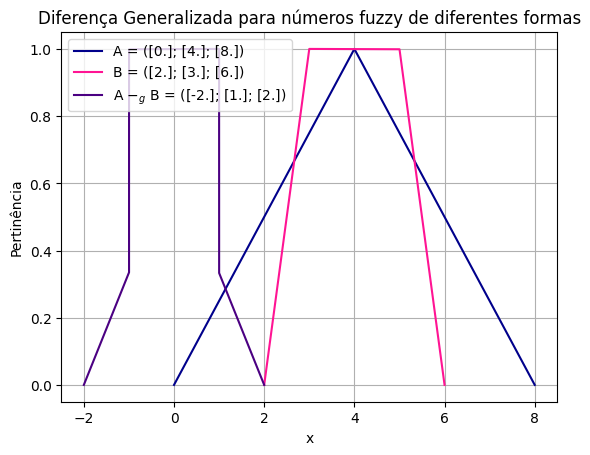

In [36]:
### EXEMPLO

A, alphas = alpha_niveis((0,4,8))
B, alphas = alpha_niveis((2,3,5,6))
### corrigir ghuk para aceitar n° de alpha níveis par
### corrigir plota_oper_fuzzy para aceitar n° de alpha níveis par

D = dif_g(A, B)

plota_oper_fuzzy(A,B,D, aniveis = alphas, oper_str="$-_{g}$", titulo = "Diferença Generalizada para números fuzzy de diferentes formas")

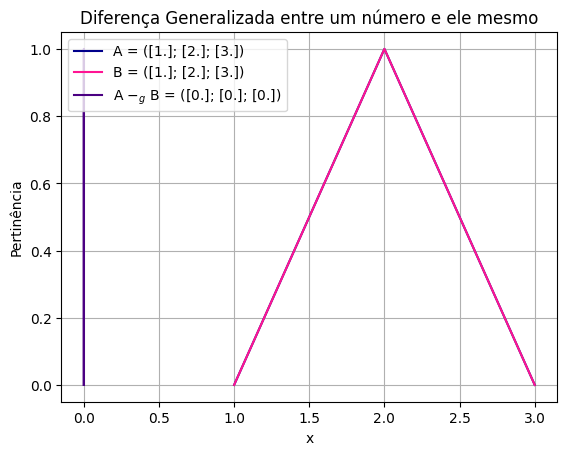

In [37]:
### EXEMPLO

A,alpha = alpha_niveis((1,2,3))

Z = dif_g(A, A)

plota_oper_fuzzy(A,A,Z, aniveis = alphas, oper_str="$-_{g}$", titulo = "Diferença Generalizada entre um número e ele mesmo")

#### Diferença Interativa $+_0$

In [38]:
def oposto_ntfuzzy(x):
    """
    Calcula o oposto de um número fuzzy, ou seja, realiza o produto entre -1 e um número triangular fuzzy.

    Args:
        x (tuple or array-like): número triangular fuzzy x na forma x = (a,b,c).

    Returns:
        x_oposto (tuple): número triangular fuzzy oposto a x (-x = (-c, -b, -a)).
        
    """
    
    a,b,c = x
    x_oposto = (-c, -b, -a)
    return x_oposto

In [39]:
def dif_interativa_0 (x1,x2):
    """
    Realiza a diferença otimista (gamma zero) de dois números triangulares fuzzy, segundo Wasques et al. (2020b).

    Args:
        x1 (tuple or array-like): número triangular fuzzy x1 na forma x1 = (a,b,c).
        x2 (tuple or array-like): número triangular fuzzy x2 na forma x2 = (d,e,f).

    Returns:
        x_dif (tuple): número triangular fuzzy resultante da diferença otimista.
        
    """
    
    x2_ = oposto_ntfuzzy(x2)
    x_dif = soma_interativa_0(x1, x2_)
    
    return x_dif

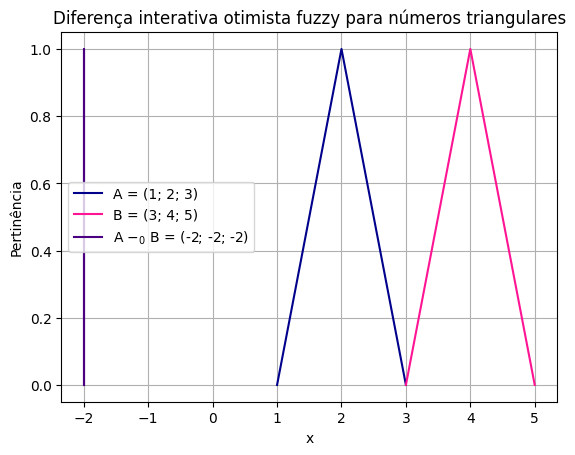

In [40]:
### EXEMPLO

A = (1,2,3)
B = (3,4,5)

D = dif_interativa_0(A, B)

plota_oper_fuzzy(A,B,D, oper_str="$-_0$", titulo = "Diferença interativa otimista fuzzy para números triangulares")

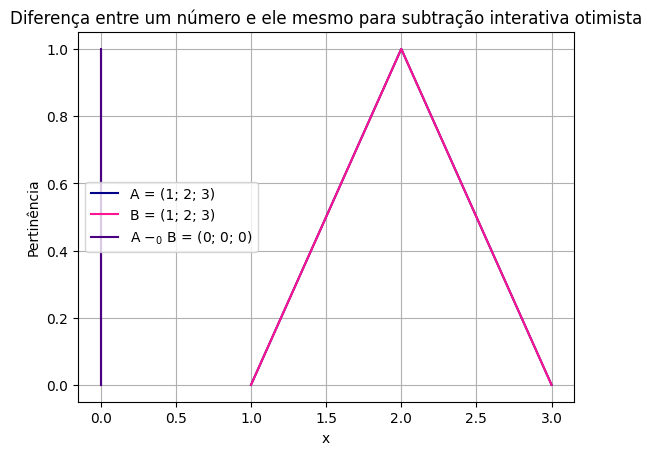

In [41]:
### EXEMPLO

A = (1,2,3)

Z = dif_interativa_0(A, A)

plota_oper_fuzzy(A,A,Z, oper_str="$-_0$", titulo = "Diferença entre um número e ele mesmo para subtração interativa otimista")

## Multiplicação

---

### Multiplicação Usual

$$ [P \cdot Q]^\alpha = [P]^\alpha \,[Q]^\alpha = [\,\min Z,\; \max Z\,],
        \quad Z = \bigl\{\,p_1^\alpha q_1^\alpha,\; p_1^\alpha q_2^\alpha,\; p_2^\alpha q_1^\alpha,\; p_2^\alpha q_2^\alpha\bigr\} $$

In [42]:
def multiplicacao_ntrifuzzy(x_num, x_den):
    """
    Realiza a divisão intervalar de dois números triangulares fuzzy a partir de seus alpha-niveis.

    Args:
        x_num (tuple or array-like): número triangular fuzzy x_num na forma x_num = (an, bn, cn), numerador na divisão.
        x_den (tuple or array-like): número triangular fuzzy x_den na forma x_den = (ad, bd, cd), denominador na divisão.

    Returns:
        x_quo_alpha (list of np.ndarray): lista de vetores colunas (n x 1) representando os valores de x_quo em função dos alpha-níveis, em que cada vetor corresponde a um intervalo da função de pertinência por partes.
    """
    
    alpha = np.arange(0, 1.001, 0.001).reshape((-1,1))
    
    n1 = _aplica_funcao(alpha, f_alpha_ntrifuzzy(x_num)[0])
    n2 = _aplica_funcao(alpha, f_alpha_ntrifuzzy(x_num)[1])
    d1 = _aplica_funcao(alpha, f_alpha_ntrifuzzy(x_den)[0])
    d2 = _aplica_funcao(alpha, f_alpha_ntrifuzzy(x_den)[1])

    caso1 = [(i*j).item() for i, j in zip(n1, d1)]
    caso2 = [(i*j).item() for i, j in zip(n1, d2)]
    caso3 = [(i*j).item() for i, j in zip(n2, d1)]
    caso4 = [(i*j).item() for i, j in zip(n2, d2)]

    x_p1 = []
    x_p2 = []
         
    for i in range(len(alpha)):
        p1_i = min(caso1[i], caso2[i], caso3[i], caso4[i])
        p2_i = max(caso1[i], caso2[i], caso3[i], caso4[i])
        x_p1.append(p1_i)
        x_p2.append(p2_i)
 
    x_prod_alpha = [x_p1,x_p2]
    
    return x_prod_alpha

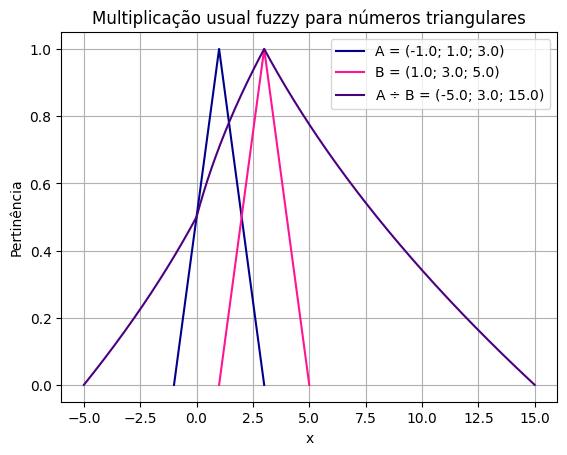

In [43]:
### EXEMPLO

A = (-1,1,3)
B = (1,3,5)

A1 =  np.linspace(A[0], A[1], 1001)
A2 = np.linspace(A[1], A[2], 1001)[1:]
B1 =  np.linspace(B[0], B[1], 1001)
B2 = np.linspace(B[1], B[2], 1001)[1:]

A_ = np.concatenate([A1, A2])
B_ = np.concatenate([B1, B2])

aniveis = np.arange(0, 1.001, 0.001)
aniveis = np.concatenate([aniveis[:-1], aniveis[::-1]])

P = multiplicacao_ntrifuzzy(A, B)
P_ =  np.concatenate([P[0][:-1], P[1][::-1]])

plota_oper_fuzzy(A_,B_,P_, aniveis = aniveis, oper_str="$÷$", titulo = "Multiplicação usual fuzzy para números triangulares")

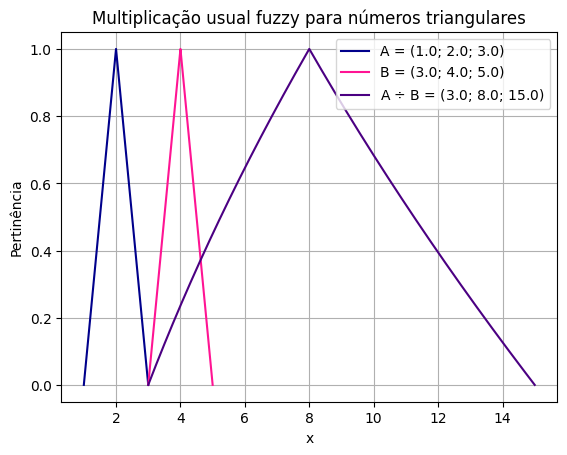

In [44]:
### EXEMPLO

A = (1,2,3)
B = (3,4,5)

A1 =  np.linspace(A[0], A[1], 1001)
A2 = np.linspace(A[1], A[2], 1001)[1:]
B1 =  np.linspace(B[0], B[1], 1001)
B2 = np.linspace(B[1], B[2], 1001)[1:]

A_ = np.concatenate([A1, A2])
B_ = np.concatenate([B1, B2])

aniveis = np.arange(0, 1.001, 0.001)
aniveis = np.concatenate([aniveis[:-1], aniveis[::-1]])

P = multiplicacao_ntrifuzzy(A, B)
P_ =  np.concatenate([P[0][:-1], P[1][::-1]])

plota_oper_fuzzy(A_,B_,P_, aniveis = aniveis, oper_str="$÷$", titulo = "Multiplicação usual fuzzy para números triangulares")

## Divisão

---

### Divisão Usual

$$ \left[\frac{P}{Q}\right]^\alpha = \frac{[P]^\alpha}{[Q]^\alpha} =
        [\,p_1^\alpha,\; p_2^\alpha\,]
        \;\left[\,\tfrac1{q_2^\alpha},\; \tfrac1{q_1^\alpha}\right]
        = [\,\min Z,\; \max Z\,],
        \;Z = \Bigl\{\,\tfrac{p_1^\alpha}{q_1^\alpha},\;\tfrac{p_1^\alpha}{q_2^\alpha},\;\tfrac{p_2^\alpha}{q_1^\alpha},\;\tfrac{p_2^\alpha}{q_2^\alpha}\Bigr\} $$

In [45]:
def divisao_ntrifuzzy(x_num, x_den):
    """
    Realiza a divisão intervalar de dois números triangulares fuzzy a partir de seus alpha-niveis.

    Args:
        x_num (tuple or array-like): número triangular fuzzy x_num na forma x_num = (an, bn, cn), numerador na divisão.
        x_den (tuple or array-like): número triangular fuzzy x_den na forma x_den = (ad, bd, cd), denominador na divisão.

    Returns:
        x_quo_alpha (list of np.ndarray): lista de vetores colunas (n x 1) representando os valores de x_quo em função dos alpha-níveis, em que cada vetor corresponde a um intervalo da função de pertinência por partes.
    """
    
    alpha = np.arange(0, 1.001, 0.001).reshape((-1,1))
    
    n1 = _aplica_funcao(alpha, f_alpha_ntrifuzzy(x_num)[0])
    n2 = _aplica_funcao(alpha, f_alpha_ntrifuzzy(x_num)[1])
    d1 = _aplica_funcao(alpha, f_alpha_ntrifuzzy(x_den)[0])
    d2 = _aplica_funcao(alpha, f_alpha_ntrifuzzy(x_den)[1])

    caso1 = [(i / j).item() for i, j in zip(n1, d1)]
    caso2 = [(i / j).item() for i, j in zip(n1, d2)]
    caso3 = [(i / j).item() for i, j in zip(n2, d1)]
    caso4 = [(i / j).item() for i, j in zip(n2, d2)]

    x_q1 = []
    x_q2 = []
         
    for i in range(len(alpha)):
        q1_i = min(caso1[i], caso2[i], caso3[i], caso4[i])
        q2_i = max(caso1[i], caso2[i], caso3[i], caso4[i])
        x_q1.append(q1_i)
        x_q2.append(q2_i)
 
    x_quo_alpha = [x_q1,x_q2]
    
    return x_quo_alpha


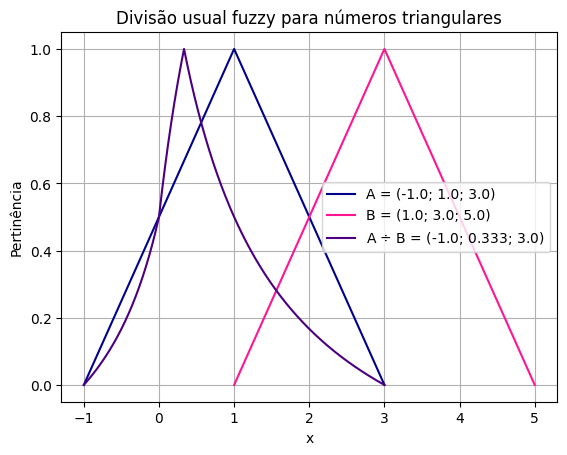

In [46]:
### EXEMPLO

A = (-1,1,3)
B = (1,3,5)

A1 =  np.linspace(A[0], A[1], 1001)
A2 = np.linspace(A[1], A[2], 1001)[1:]
B1 =  np.linspace(B[0], B[1], 1001)
B2 = np.linspace(B[1], B[2], 1001)[1:]

A_ = np.concatenate([A1, A2])
B_ = np.concatenate([B1, B2])

aniveis = np.arange(0, 1.001, 0.001)
aniveis = np.concatenate([aniveis[:-1], aniveis[::-1]])

D = divisao_ntrifuzzy(A, B)
D_ =  np.concatenate([D[0][:-1], D[1][::-1]])

plota_oper_fuzzy(A_,B_,D_, aniveis = aniveis, oper_str="$÷$", titulo = "Divisão usual fuzzy para números triangulares")

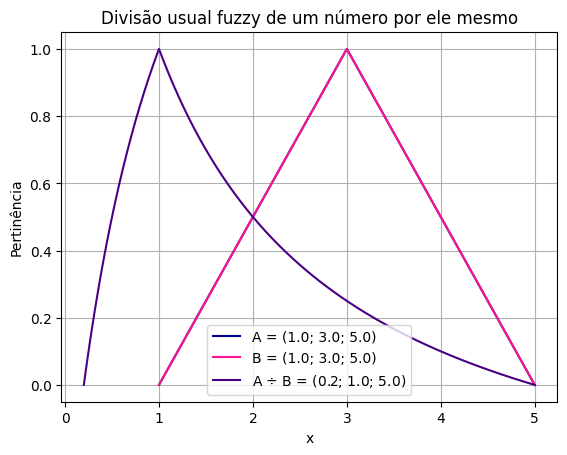

In [47]:
### EXEMPLO

B = (1,3,5)

B1 =  np.linspace(B[0], B[1], 1001)
B2 = np.linspace(B[1], B[2], 1001)[1:]

B_ = np.concatenate([B1, B2])

aniveis = np.arange(0, 1.001, 0.001)
aniveis = np.concatenate([aniveis[:-1], aniveis[::-1]])

D = divisao_ntrifuzzy(B, B)
D_ =  np.concatenate([D[0][:-1], D[1][::-1]])

plota_oper_fuzzy(B_,B_,D_, aniveis = aniveis, oper_str="$÷$", titulo = "Divisão usual fuzzy de um número por ele mesmo")

### Divisões Interativas

#### Divisao Generalizada ou g-divisão ($\div_g$)
$$
\begin{equation}\label{eq:gdiv}
    [R]_\alpha=[P]_\alpha\oslash_g[Q]_\alpha\Leftrightarrow \begin{cases}
        (i) & [P]_\alpha=[Q]_\alpha[R]_\alpha, \text{ ou}\\
        (ii) & [Q]_\alpha=[P]_\alpha[R]_\alpha^{-1}
    \end{cases},
\end{equation}$$
em que $[R]_\alpha^{-1}=\displaystyle\left[\frac{1}{r_2^\alpha},\frac{1}{r_1^\alpha}\right].$

Se $[P]_\alpha\oslash_g[Q]_\alpha$ não resultar em um número fuzzy, então Stefanini propôs a divisão generalizada $\widetilde{\oslash_g}$, dada por
$$[P\widetilde{\oslash_g}Q] \mathrel{:=} \text{cl}\left(\bigcup_{\beta\geq\alpha}[P]_\beta\oslash_g[Q]_\beta\right),$$
sendo que $cl$ representa o fecho do conjunto.

In [48]:
def gdivisao_ntrifuzzy(x_num, x_den):
    """    
    Realiza a divisão generalizada de dois números triangulares fuzzy a partir de seus alpha-niveis, segundo Stefanini (2010).

    Args:
        x_num (tuple or array-like): número triangular fuzzy x_num na forma x_num = (an, bn, cn), numerador na divisão.
        x_den (tuple or array-like): número triangular fuzzy x_den na forma x_den = (ad, bd, cd), denominador na divisão.

    Returns:
        x_g_quo (list of np.ndarray): lista de vetores colunas (n x 1) representando os valores de x_g_quo em função dos alpha-níveis, em que cada vetor corresponde a um intervalo da função de pertinência por partes.
    """ 
    
    # divisão em casos
    def caso_1(a1, a2, b1, b2):
        caso1 = (0 < a1 <= a2) and (b1 <= b2 < 0)
        return caso1
    
    def caso_11(a1, a2, b1, b2):
        caso11 = (a1*b1 >= a2*b2)
        return caso11
    
    def caso_12(a1, a2, b1, b2):  
        caso12 = (a1*b1 <= a2*b2)
        return caso12
    
    
    def caso_2(a1, a2, b1, b2):
        caso2 = (0 < a1 <= a2) and (0 < b1 <= b2)
        return caso2
    
    def caso_21(a1, a2, b1, b2):
        caso21 = (a1*b2 <= a2*b1)
        return caso21
    
    def caso_22(a1, a2, b1, b2):
        caso22 = (a1*b2 >= a2*b1)
        return caso22
    
    
    def caso_3(a1, a2, b1, b2):
        caso3 = (a1 <= a2 < 0) and (b1 <= b2 < 0)
        return caso3
    
    def caso_31(a1, a2, b1, b2):
        caso31 = (a2*b1 <= a1*b2)
        return caso31
    
    def caso_32(a1, a2, b1, b2):
        caso32 = (a2*b1 >= a1*b2)
        return caso32
    
    
    def caso_4(a1, a2, b1, b2):
        caso4 = (a1 <= a2 < 0) and (0 < b1 <= b2)
        return caso4
    
    def caso_41(a1, a2, b1, b2):
        caso41 = (a1*b1 <= a2*b2)
        return caso41
    
    def caso_42(a1, a2, b1, b2):
        caso42 = (a1*b1 >= a2*b2)
        return caso42
    
    
    def caso_5(a1, a2, b1, b2):   
        caso5 = (a1 <= 0) and (a2 >= 0) and (b1 <= b2 < 0)
        return caso5
        
        
    def caso_6(a1, a2, b1, b2):
        caso6 = (a1 <= 0) and (a2 >= 0) and (0 < b1 <= b2)
        return caso6
    
    
    alpha = np.arange(0, 1.001, 0.001).reshape((-1,1))
    
    n1 = _aplica_funcao(alpha, f_alpha_ntrifuzzy(x_num)[0])
    n2 = _aplica_funcao(alpha, f_alpha_ntrifuzzy(x_num)[1])
    d1 = _aplica_funcao(alpha, f_alpha_ntrifuzzy(x_den)[0])
    d2 = _aplica_funcao(alpha, f_alpha_ntrifuzzy(x_den)[1])
    
#    n_a =  len(x_num)
    
    quo1 = []
    quo2 = []
    
    
    count = 0
    
#     left_num  = x_num[:n_a//2 +1]
#     right_num = x_num[n_a//2:][::-1]

#     left_den  = x_den[:n_a//2 +1]
#     right_den = x_den[n_a//2:][::-1]
    
    
    #definição dos alpha-níveis
    for xn1, xn2, xd1, xd2 in zip(n1, n2, d1, d2):
    #for xn1, xn2, xd1, xd2 in zip(x_num[:(n_a)//2],x_num[(n_a)//2::-1], x_den[:(n_a)//2],x_den[(n_a)//2::-1]) :
    
        caso1 = caso_1(xn1,xn2,xd1,xd2)
        caso11 = caso_11(xn1,xn2,xd1,xd2)
        caso12 = caso_12(xn1,xn2,xd1,xd2)

        caso2 = caso_2(xn1,xn2,xd1,xd2)
        caso21 = caso_21(xn1,xn2,xd1,xd2)
        caso22 = caso_22(xn1,xn2,xd1,xd2)

        caso3 = caso_3(xn1,xn2,xd1,xd2)
        caso31 = caso_31(xn1,xn2,xd1,xd2)
        caso32 = caso_32(xn1,xn2,xd1,xd2)

        caso4 = caso_4(xn1,xn2,xd1,xd2)
        caso41 = caso_41(xn1,xn2,xd1,xd2)
        caso42 = caso_42(xn1,xn2,xd1,xd2)

        caso5 = caso_5(xn1,xn2,xd1,xd2)
        caso6 = caso_6(xn1,xn2,xd1,xd2)

    #    # definição de g-divisão
    #     def1 = (x_num == x_den * x_quo)
    #     def2 = (x_den == x_num * x_quo_inv)

        definicao = "zero"
        defs = []
        
        a1 = round(xn1[0],12)
        a2 = round(xn2[0],12)
        b1 = round(xd1[0],12)
        b2 = round(xd2[0],12)
        
        #Aplicação dos casos
        if caso1:
            if caso11:
                c1 = a2/b1
                c2 = a1/b2
                def_new = r"$N=DQ$"
            elif caso12:
                c1 = a1/b2
                c2 = a2/b1
                def_new = r"$D=NQ^{-1}$"
            else:
                raise ValueError(f"O alpha-nível de iteração {count}, com numerador {[a1, a2]} e denominador {[b1,b2]}, se encaixa no caso 1, mas não se encaixa em nenhum subcaso")
            
        elif caso2:
            if caso21:
                c1 = a1/b1
                c2 = a2/b2
                def_new = r"$N=DQ$"
            elif caso22:
                c1 = a2/b2
                c2 = a1/b1   
                def_new = r"$D=NQ^{-1}$"
            else:
                raise ValueError(f"O alpha-nível de iteração {count}, com numerador {[a1, a2]} e denominador {[b1,b2]}, se encaixa no caso 2, mas não se encaixa em nenhum subcaso")
          
        elif caso3:
            if caso31:
                c1 = a2/b2
                c2 = a1/b1
                def_new = r"$N=DQ$"
            elif caso32:
                c1 = a1/b1
                c2 = a2/b2
                def_new = r"$D=NQ^{-1}$"
            else:
                raise ValueError(f"O alpha-nível de iteração {count}, com numerador {[a1, a2]} e denominador {[b1,b2]}, se encaixa no caso 3, mas não se encaixa em nenhum subcaso")
            
        elif caso4: 
            if caso41:
                c1 = a1/b2
                c2 = a2/b1
                def_new = r"$N=DQ$"
            elif caso42:
                c1 = a2/b1
                c2 = a1/b2   
                def_new = r"$D=NQ^{-1}$"
            else:
                raise ValueError(f"O alpha-nível de iteração {count}, com numerador {[a1, a2]} e denominador {[b1,b2]}, se encaixa no caso 4, mas não se encaixa em nenhum subcaso")
        
        elif caso5:
            c1 = a2/b1
            c2 = a1/b1
            def_new = r"$N=DQ$"

        elif caso6:         
            c1 = a1/b2
            c2 = a2/b2
            def_new = r"$N=DQ$"
            
        else:
            raise ValueError(f"O alpha-nível de iteração {count}, com numerador {[a1, a2]} e denominador {[b1,b2]}, não se encaixa em nenhum caso!")
            
        quo1.append(c1)
        quo2.append(c2)
        
        if definicao != def_new:
            definicao = def_new
            defs.append(definicao)
            
        count += 1
    
    x_quo = quo1[:-1] + quo2[::-1]
    
    return x_quo, defs

['$N=DQ$']


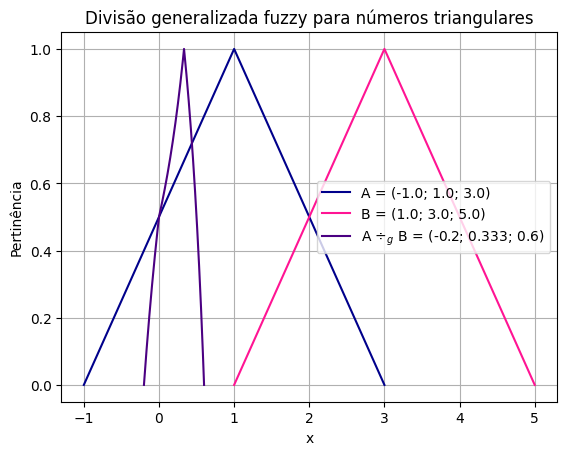

In [49]:
### EXEMPLO

A = (-1,1,3)
B = (1,3,5)

A1 =  np.linspace(A[0], A[1], 1001)[:-1]
A2 = np.linspace(A[1], A[2], 1001)
B1 =  np.linspace(B[0], B[1], 1001)[:-1]
B2 = np.linspace(B[1], B[2], 1001)

A_ = np.concatenate([A1, A2])
B_ = np.concatenate([B1, B2])

aniveis = np.arange(0, 1.001, 0.001)
aniveis = np.concatenate([aniveis[:-1], aniveis[::-1]])

D, defs = gdivisao_ntrifuzzy(A, B)

print(defs)
plota_oper_fuzzy(A_,B_,D, aniveis = aniveis, oper_str="$÷_g$", titulo = "Divisão generalizada fuzzy para números triangulares")

['$N=DQ$']


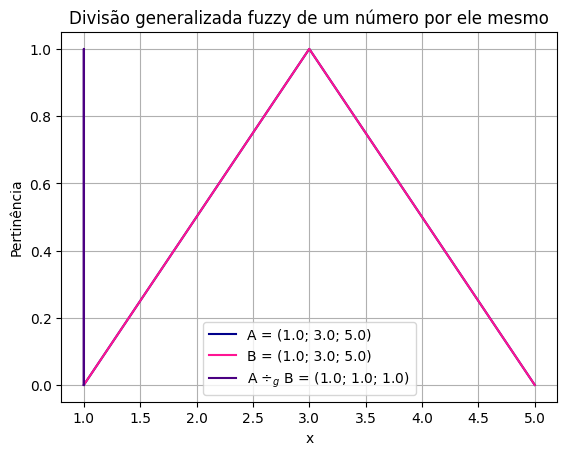

In [50]:
### EXEMPLO

B = (1,3,5)

B1 =  np.linspace(B[0], B[1], 1001)
B2 = np.linspace(B[1], B[2], 1001)[1:]

B_ = np.concatenate([B1, B2])

aniveis = np.arange(0, 1.001, 0.001)
aniveis = np.concatenate([aniveis[:-1], aniveis[::-1]])

D, defs = gdivisao_ntrifuzzy(B, B)

print(defs)
plota_oper_fuzzy(B_,B_,D, aniveis = aniveis, oper_str="$÷_g$", titulo = "Divisão generalizada fuzzy de um número por ele mesmo")

In [51]:
### EXEMPLO

A = (-1,1,3)
B = (1,3,5)

A1 =  np.linspace(A[0], A[1], 1001)[:-1]
A2 = np.linspace(A[1], A[2], 1001)
B1 =  np.linspace(B[0], B[1], 1001)[:-1]
B2 = np.linspace(B[1], B[2], 1001)

A_ = np.concatenate([A1, A2])
B_ = np.concatenate([B1, B2])

aniveis = np.arange(0, 1.001, 0.001)
aniveis = np.concatenate([aniveis[:-1], aniveis[::-1]])

D, defs = gdivisao_ntrifuzzy(B, A)

print(defs)
plota_oper_fuzzy(B_,A_,D, aniveis = aniveis, oper_str="$÷_g$", titulo = "Divisão generalizada fuzzy para números triangulares")

ValueError: O alpha-nível de iteração 0, com numerador [1.0, 5.0] e denominador [-1.0, 3.0], não se encaixa em nenhum caso!